# 02 · P300 classification and character selection

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Train a shrinkage LDA detector on real EEG, evaluate an unseen session, and implement row/column evidence accumulation with explicitly simulated flash metadata.

**Data:** Real BNCI2014-009 target detection; separate labeled speller simulation

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

You must decide whether the next flash contains the attended symbol. False positives can select a wrong row; false negatives can delay a decision. We will derive a linear score, distinguish ranking from a decision threshold, and then show how repeated flash evidence becomes a character selection.

### By the end you should be able to

- Derive a two-class LDA direction and explain covariance shrinkage.
- Separate fitting, probability/ranking scores and threshold decisions.
- Compute confusion-matrix metrics by hand before using library functions.
- Aggregate row/column evidence while preserving character and repetition IDs.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### From a feature vector to a decision

Let $z\in\mathbb R^p$ contain the temporal means from several channels and windows. LDA assumes $z|y=k\sim\mathcal N(\mu_k,\Sigma)$ with one shared covariance. Subtracting the two log Gaussian densities cancels their common quadratic term, leaving a linear score:

$$g(z)=z^T\Sigma^{-1}(\mu_1-\mu_0)-\tfrac12(\mu_1+\mu_0)^T\Sigma^{-1}(\mu_1-\mu_0)+\log(\pi_1/\pi_0).$$

Here $\pi_k$ is the class prior. The direction says which combination of features separates the means after accounting for covariance. The intercept includes prior odds: targets are rarer, so equal evidence need not imply a target decision. A classifier with useful AUC may still miss many targets at its default threshold.

Why covariance? Two neighboring EEG features may contain nearly the same information. Counting both as independent would overstate the evidence. But estimating a full $p\times p$ covariance requires many parameters; with correlated or scarce trials the inverse becomes unstable. Shrinkage pulls the estimate toward a simpler matrix. It trades some bias for reduced estimation variance. Standardization is learned from training data, not a ritual to perform on the entire dataset first.

### Choose a metric that matches the question

Accuracy counts correct decisions; balanced accuracy averages recalls so the abundant class does not dominate. ROC AUC assesses ordering over all thresholds. Average precision emphasizes precision/recall in the positive class and its baseline depends on positive prevalence. None measures the number of correctly typed characters per minute. Report the unit of prediction and the unit of communication separately.

In this lesson the first sessions calibrate a fixed model and the last session evaluates it. Inspecting that last score repeatedly while changing features would turn it into a validation set. The later controlled speller simulation has known flash identities, so aggregation can be checked exactly; it does not upgrade the real-data experiment into a validated text-entry system.

### Worked example · solve a two-feature LDA direction

Two feature means differ in both coordinates, but the first coordinate has much larger within-class variance. Predict which feature receives more weight. Use a linear solver rather than explicitly inverting the covariance.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_mu0=np.array([0.,0.]);demo_mu1=np.array([1.,1.])
demo_cov=np.diag([4.,.25])
demo_w=np.linalg.solve(demo_cov,demo_mu1-demo_mu0)
print('LDA direction:',demo_w)
print('Mean contrast before covariance adjustment:',demo_mu1-demo_mu0)
assert demo_w[1]>demo_w[0]

LDA direction: [0.25 4.  ]
Mean contrast before covariance adjustment: [1. 1.]


**Read the result.** The less variable feature gets a larger weight in this example. Large weights are not automatically large physiological effects; units and covariance matter.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · compute the confusion matrix metrics

Suppose 80 non-target flashes are classified correctly, 10 become false targets, 6 targets are detected and 4 are missed. Compute accuracy, precision, recall and balanced accuracy before reading the output.

**Before running:** state your prediction and the assumption behind it.

In [3]:
TN,FP,TP,FN=80,10,6,4
manual_metrics={'accuracy':(TP+TN)/(TP+TN+FP+FN),
 'target_precision':TP/(TP+FP),'target_recall':TP/(TP+FN),
 'balanced_accuracy':.5*(TP/(TP+FN)+TN/(TN+FP))}
print(pd.Series(manual_metrics).round(3))

accuracy             0.860
target_precision     0.375
target_recall        0.600
balanced_accuracy    0.744
dtype: float64


**Read the result.** The overall accuracy can look comfortable while target precision is poor. An interface may need more repetitions or a rejection state even when ranking performance is useful.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · move the threshold

Hold scores fixed and change only the threshold. This changes decisions, not the underlying ranking. The following data are synthetic, so the curve explains a tradeoff rather than reporting participant performance.

**Before running:** state your prediction and the assumption behind it.

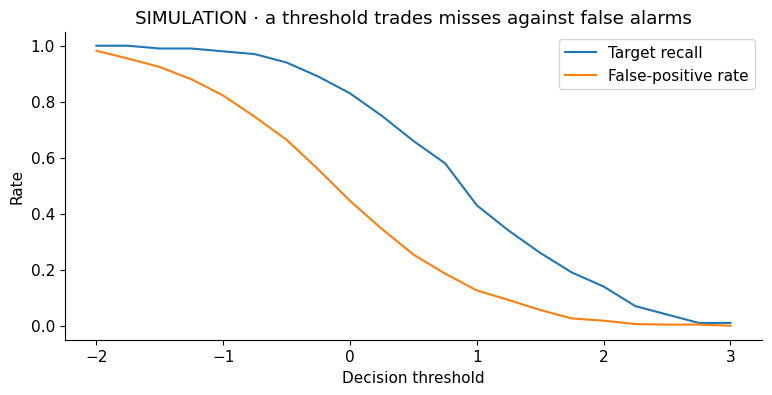

In [4]:
demo_y=np.r_[np.zeros(500,dtype=int),np.ones(100,dtype=int)]
demo_scores=rng.normal(demo_y*.9,1)
threshold_rows=[]
for threshold in np.linspace(-2,3,21):
    decision=demo_scores>=threshold
    recall=decision[demo_y==1].mean()
    false_positive=decision[demo_y==0].mean()
    threshold_rows.append((threshold,recall,false_positive))
threshold_rows=np.array(threshold_rows)
fig,ax=plt.subplots()
ax.plot(threshold_rows[:,0],threshold_rows[:,1],label='Target recall')
ax.plot(threshold_rows[:,0],threshold_rows[:,2],label='False-positive rate')
ax.set(xlabel='Decision threshold',ylabel='Rate',title='SIMULATION · a threshold trades misses against false alarms')
ax.legend();plt.show()

**Read the result.** Do not choose an operating threshold using the evaluation labels. A separate validation set or grouped calibration predictions are needed.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · evidence accumulation by hand

Flash groups 0–5 denote rows and 6–11 columns. Add evidence across repetitions first, then take separate maxima. Taking one maximum over all twelve groups would produce a group, not a character.

**Before running:** state your prediction and the assumption behind it.

In [5]:
demo_scores_grid=np.zeros((1,3,12))
demo_scores_grid[0,:,2]=[.5,1.,.7]
demo_scores_grid[0,:,10]=[.6,.8,1.2]
demo_totals=demo_scores_grid.sum(1)
demo_row=demo_totals[:,:6].argmax(1)
demo_col=demo_totals[:,6:].argmax(1)
print('Row, column:',demo_row,demo_col)
print('Flat symbol index:',demo_row*6+demo_col)
assert (demo_row*6+demo_col)[0]==16

Row, column: [2] [4]
Flat symbol index: [16]


**Read the result.** Aggregation requires correct flash-group metadata. It cannot be reconstructed safely from binary target labels alone.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

Linear discriminant analysis models each class with a mean $\mu_k$ and a common covariance $\Sigma$. Its binary direction is $w=\Sigma^{-1}(\mu_1-\mu_0)$. Shrinkage uses $\Sigma_\lambda=(1-\lambda)\hat\Sigma+\lambda\alpha I$ to stabilize estimates when features are numerous or correlated. Scaling and covariance estimation belong inside the training pipeline.

ROC AUC measures ranking over thresholds: it is the probability a random target receives a higher score than a random non-target. Balanced accuracy is $(\mathrm{TPR}+\mathrm{TNR})/2$. Neither equals character accuracy. A row/column decoder adds flash evidence: $S_j=\sum_r s_{rj}$, then chooses the row and column with largest accumulated score. The mapping from flash to row/column must come from the experiment log; binary target labels cannot reconstruct it.

For $M$ equally likely commands, accuracy $P$ and decision duration $T$ seconds, the idealized information-transfer rate is $\mathrm{ITR}=\frac{60}{T}[\log_2 M+P\log_2P+(1-P)\log_2\frac{1-P}{M-1}]$. Its symmetric-error and independent-selection assumptions can fail; report actual selection time, correction time and a confusion matrix too.

## Load and separate sessions
Keep the final session completely outside fitting. All preprocessing settings are fixed in advance.

The final session is reserved before model fitting. The temporal windows are fixed in advance, and the label vector remains aligned with the metadata. Keeping entire sessions separate prevents trial-level random splitting from obscuring recording-session transfer.

In [6]:
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300
dataset = BNCI2014_009()
paradigm = P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)
epochs, labels, metadata_p300 = paradigm.get_data(
    dataset=dataset, subjects=[1], return_epochs=True)
y = (np.asarray(labels) == 'Target').astype(int)
X = epochs.get_data(copy=True)  # volts; epochs x channels x samples
session = metadata_p300['session'].astype(str).to_numpy()
assert X.shape[0] == len(y) == len(session)
assert set(np.unique(y)) == {0, 1}
print(pd.crosstab(session, np.asarray(labels)))
print('Shape:', X.shape, 'sampling:', epochs.info['sfreq'], 'Hz')

train = session != sorted(np.unique(session))[-1]
test = ~train
windows = [(0.1,.25),(.25,.4),(.4,.6),(.6,.8)]
features = np.concatenate([X[:,:,(epochs.times>=a)&(epochs.times<b)].mean(-1)
                           for a,b in windows], axis=1)
assert set(session[train]).isdisjoint(set(session[test]))

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


col_0  NonTarget  Target
row_0                   
0            480      96
1            480      96
2            480      96
Shape: (1728, 16, 103) sampling: 128.0 Hz


### Inspect and interpret

Print the session identifiers assigned to each partition and verify no overlap. Check that both classes occur in calibration and test. A pipeline cannot repair an incorrectly constructed partition.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Fit and evaluate
LDA priors reflect training prevalence. AUC uses continuous scores; threshold-based metrics use the default decision boundary, without test-set tuning.

The scaler learns only calibration statistics; shrinkage LDA then estimates a regularized linear discriminant. `decision_function` yields continuous scores for AUC, while `predict` gives labels for balanced accuracy and the confusion matrix. These metrics answer different questions.

Held-out session AUC: 0.8749131944444444
Balanced accuracy: 0.7333333333333334
              precision    recall  f1-score   support

  Non-target       0.91      0.95      0.93       480
      Target       0.66      0.52      0.58        96

    accuracy                           0.88       576
   macro avg       0.78      0.73      0.75       576
weighted avg       0.87      0.88      0.87       576



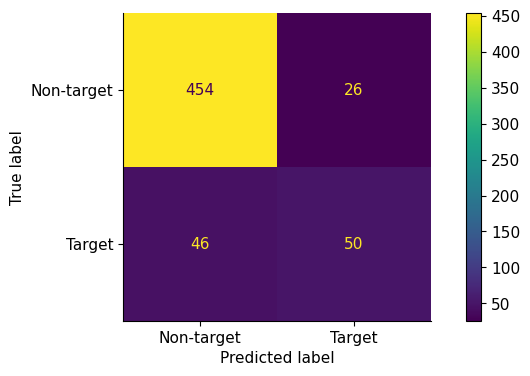

In [7]:
model = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
model.fit(features[train], y[train])
scores = model.decision_function(features[test])
pred = model.predict(features[test])
print('Held-out session AUC:', roc_auc_score(y[test], scores))
print('Balanced accuracy:', balanced_accuracy_score(y[test], pred))
print(classification_report(y[test], pred, target_names=['Non-target','Target'], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y[test], pred, display_labels=['Non-target','Target'])
plt.show()

### Inspect and interpret

Read the target recall and non-target recall separately. Explain how a model can rank targets reasonably while producing few target predictions at its default threshold. Any threshold change must be selected on calibration data.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Decode characters with known flash identity
This separate simulation teaches aggregation only. Scores are simulated, not predictions on the real speller data; do not report its accuracy as experimental performance.

The next example is explicitly synthetic because trial classification alone does not preserve the full character-selection protocol. Known row and column flash identities let us sum evidence across repetitions and select their intersection. No real-data spelling accuracy is inferred from this simulation.

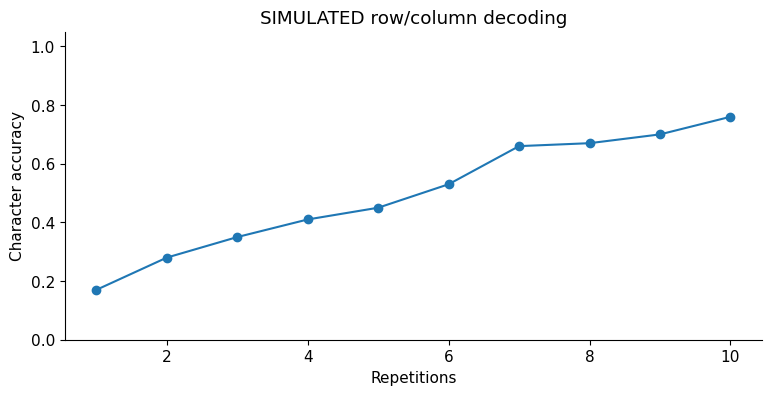

Example target: Y decoded: 2


In [8]:
alphabet = np.array(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')).reshape(6,6)
n_characters, repetitions = 100, 10
truth = rng.integers(0,36,n_characters)
flash_scores = rng.normal(0,1,(n_characters,repetitions,12))
for i, target in enumerate(truth):
    row, col = divmod(int(target),6)
    flash_scores[i,:,row] += 0.8
    flash_scores[i,:,6+col] += 0.8
accuracy = []
for r in range(1,repetitions+1):
    total = flash_scores[:,:r].sum(axis=1)
    selected = total[:,:6].argmax(1)*6 + total[:,6:].argmax(1)
    accuracy.append(np.mean(selected==truth))
fig, ax = plt.subplots()
ax.plot(range(1,repetitions+1),accuracy,'o-')
ax.set(xlabel='Repetitions',ylabel='Character accuracy',ylim=(0,1.05),title='SIMULATED row/column decoding')
plt.show()
print('Example target:', alphabet.flat[truth[0]], 'decoded:', alphabet.flat[selected[0]])

### Inspect and interpret

Check that the intended character is recoverable from its row and column. Repeat with fewer repetitions or noisier scores. Explain why flashes from the same character must remain together in a character-level evaluation.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · Metrics from counts

Implement `balanced_from_counts`. Verify it gives 0.5 for an all-non-target classifier when both classes exist, regardless of imbalance.

In [9]:
def balanced_from_counts(tn, fp, fn, tp):
    # TODO: average the target and non-target recalls.
    return None

In [10]:
answer=balanced_from_counts(80,10,4,6)
if answer is not None:
    assert np.isclose(answer,.5*(80/90+6/10)); print('Metric checks passed.')
else:
    print('Exercise pending: implement balanced_from_counts.')

Exercise pending: implement balanced_from_counts.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Baseline comparison

Fit a dummy classifier and compare its accuracy and balanced accuracy with LDA on the same held-out session. Explain each difference.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Training-only model choice

Compare LDA with logistic regression using only calibration sessions for the choice. Write the choice down before reporting the held-out score.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Speller aggregation

Extend the worked flash example to three characters and verify row/column decoding against known indices. State the shape of every array.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · Speed–accuracy tradeoff

Compute idealized ITR for the simulated repetition curve using 12 flashes/repetition, 0.125 s/flash and 2 s overhead. Handle the 0·log(0) limit safely and label the result simulated.

In [14]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Explain why a high AUC does not imply a high character rate. Include thresholding, repetitions, metadata, errors and overhead in your answer.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[LDA](https://scikit-learn.org/stable/modules/lda_qda.html) · [P300 dataset](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.